
Multicollinearity Analysis using PCA

1. Condition Number Analysis:
Condition Number: 17.75
CAUTION: Moderate multicollinearity present

2. Variance Explained by Principal Components:

PC1:
  Eigenvalue: 2.009
  Variance Explained: 40.1%
  Cumulative Variance: 40.1%

PC2:
  Eigenvalue: 1.908
  Variance Explained: 38.1%
  Cumulative Variance: 78.3%

PC3:
  Eigenvalue: 0.996
  Variance Explained: 19.9%
  Cumulative Variance: 98.2%

PC4:
  Eigenvalue: 0.086
  Variance Explained: 1.7%
  Cumulative Variance: 99.9%

PC5:
  Eigenvalue: 0.006
  Variance Explained: 0.1%
  Cumulative Variance: 100.0%

3. Collinear Groups Detected:


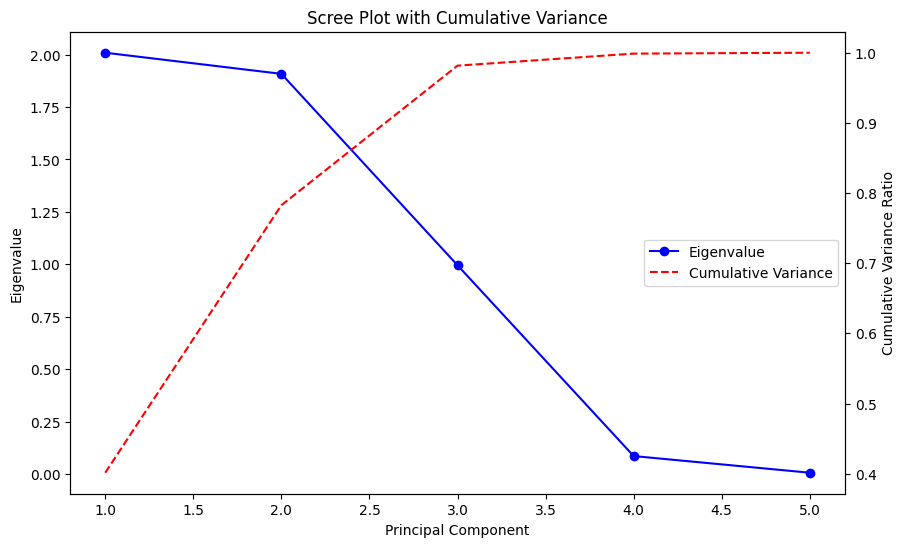

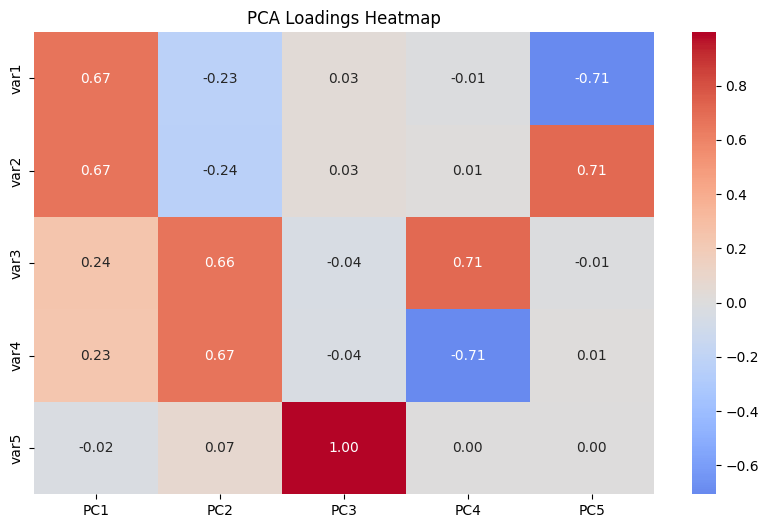

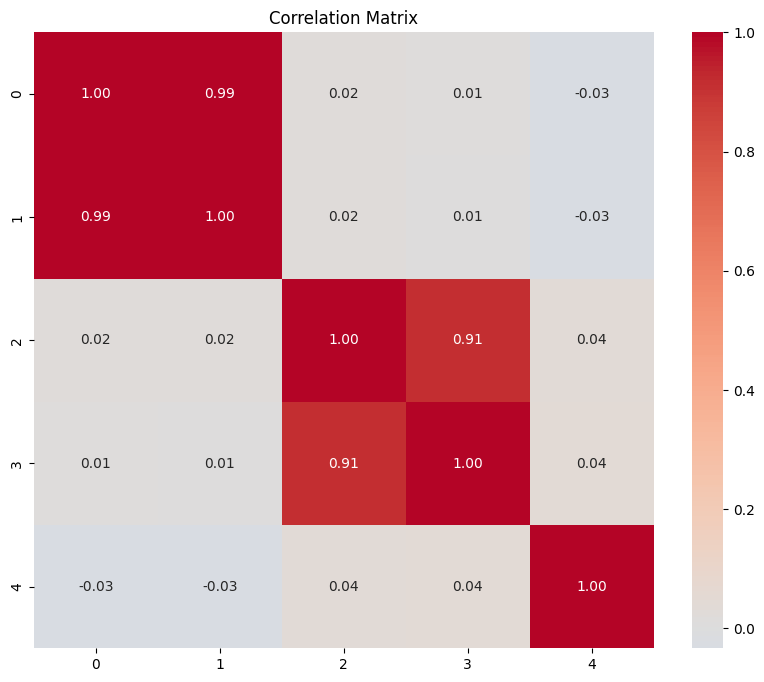

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

class MulticollinearityDetector:
    def __init__(self, data):
        self.data = data
        self.scaler = StandardScaler()
        
    def analyze_multicollinearity(self):
        """
        Comprehensive multicollinearity analysis using PCA
        """
        # Scale the data
        X_scaled = self.scaler.fit_transform(self.data)
        
        # Perform PCA
        pca_results = self._perform_pca(X_scaled)
        
        # Analyze condition number
        condition_analysis = self._analyze_condition_number(X_scaled)
        
        # Analyze variable relationships
        relationship_analysis = self._analyze_variable_relationships(
            pca_results, condition_analysis
        )
        
        return {
            'pca_results': pca_results,
            'condition_analysis': condition_analysis,
            'relationships': relationship_analysis
        }
    
    def _perform_pca(self, X_scaled):
        """
        Perform PCA and extract key metrics
        """
        pca = PCA()
        components = pca.fit_transform(X_scaled)
        
        # Calculate loadings
        loadings = pd.DataFrame(
            pca.components_.T,
            columns=[f'PC{i+1}' for i in range(len(self.data.columns))],
            index=self.data.columns
        )
        
        # Variance explained
        explained_variance = pd.DataFrame({
            'eigenvalue': pca.explained_variance_,
            'variance_ratio': pca.explained_variance_ratio_,
            'cumulative_variance_ratio': np.cumsum(pca.explained_variance_ratio_)
        })
        
        return {
            'components': components,
            'loadings': loadings,
            'explained_variance': explained_variance,
            'pca_obj': pca
        }
    
    def _analyze_condition_number(self, X_scaled):
        """
        Analyze condition number and its implications
        """
        # Calculate correlation matrix
        corr_matrix = np.corrcoef(X_scaled.T)
        
        # Calculate eigenvalues of correlation matrix
        eigenvalues = np.linalg.eigvals(corr_matrix)
        
        # Calculate condition number
        condition_number = np.sqrt(max(eigenvalues) / min(eigenvalues))
        
        return {
            'condition_number': condition_number,
            'eigenvalues': eigenvalues,
            'correlation_matrix': corr_matrix
        }
    
    def _analyze_variable_relationships(self, pca_results, condition_analysis):
        """
        Analyze relationships between variables using PCA results
        """
        # Identify highly correlated variables using loadings
        loadings = pca_results['loadings']
        
        # Calculate variable importance in each PC
        var_importance = pd.DataFrame(
            np.square(loadings),
            columns=loadings.columns,
            index=loadings.index
        )
        
        # Identify potential collinear groups
        collinear_groups = self._identify_collinear_groups(
            loadings, var_importance
        )
        
        return {
            'variable_importance': var_importance,
            'collinear_groups': collinear_groups
        }
    
    def _identify_collinear_groups(self, loadings, var_importance, threshold=0.7):
        """
        Identify groups of potentially collinear variables
        """
        groups = []
        
        # Look at loadings in first few PCs
        for pc in loadings.columns[:2]:  # Focus on first two PCs
            # Get variables with high loadings
            high_loading_vars = loadings[abs(loadings[pc]) > threshold].index
            if len(high_loading_vars) > 1:
                groups.append(list(high_loading_vars))
        
        return groups
    
    def visualize_analysis(self, results):
        """
        Create visualizations for multicollinearity analysis
        """
        # 1. Scree plot with cumulative variance
        exp_var = results['pca_results']['explained_variance']
        
        fig, ax1 = plt.subplots(figsize=(10, 6))
        ax2 = ax1.twinx()
        
        # Plot eigenvalues
        ax1.plot(range(1, len(exp_var) + 1), 
                exp_var['eigenvalue'], 
                'bo-', label='Eigenvalue')
        ax1.set_xlabel('Principal Component')
        ax1.set_ylabel('Eigenvalue')
        
        # Plot cumulative variance
        ax2.plot(range(1, len(exp_var) + 1), 
                exp_var['cumulative_variance_ratio'], 
                'r--', label='Cumulative Variance')
        ax2.set_ylabel('Cumulative Variance Ratio')
        
        plt.title('Scree Plot with Cumulative Variance')
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
        plt.show()
        
        # 2. Loading plot
        loadings = results['pca_results']['loadings']
        plt.figure(figsize=(10, 6))
        sns.heatmap(loadings, 
                   cmap='coolwarm', 
                   center=0,
                   annot=True,
                   fmt='.2f')
        plt.title('PCA Loadings Heatmap')
        plt.show()
        
        # 3. Correlation matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(results['condition_analysis']['correlation_matrix'],
                   cmap='coolwarm',
                   center=0,
                   annot=True,
                   fmt='.2f')
        plt.title('Correlation Matrix')
        plt.show()

# Generate example data with multicollinearity
def generate_multicollinear_data(n_samples=1000):
    np.random.seed(42)
    
    # Create correlated variables
    x1 = np.random.normal(0, 1, n_samples)
    x2 = 0.9 * x1 + 0.1 * np.random.normal(0, 1, n_samples)  # Strong correlation with x1
    x3 = np.random.normal(0, 1, n_samples)
    x4 = 0.7 * x3 + 0.3 * np.random.normal(0, 1, n_samples)  # Moderate correlation with x3
    x5 = np.random.normal(0, 1, n_samples)  # Independent variacoble
    
    data = pd.DataFrame({
        'var1': x1,
        'var2': x2,
        'var3': x3,
        'var4': x4,
        'var5': x5
    })
    
    return data

# Run analysis
data = generate_multicollinear_data()
detector = MulticollinearityDetector(data)
results = detector.analyze_multicollinearity()

# Print insights
print("\nMulticollinearity Analysis using PCA")
print("==================================")

print("\n1. Condition Number Analysis:")
condition_number = results['condition_analysis']['condition_number']
print(f"Condition Number: {condition_number:.2f}")
if condition_number > 30:
    print("WARNING: High multicollinearity detected")
elif condition_number > 15:
    print("CAUTION: Moderate multicollinearity present")
else:
    print("Multicollinearity appears to be within acceptable limits")

print("\n2. Variance Explained by Principal Components:")
exp_var = results['pca_results']['explained_variance']
for i, (eigen, var_ratio, cum_ratio) in exp_var.iterrows():
    print(f"\nPC{i+1}:")
    print(f"  Eigenvalue: {eigen:.3f}")
    print(f"  Variance Explained: {var_ratio:.1%}")
    print(f"  Cumulative Variance: {cum_ratio:.1%}")

print("\n3. Collinear Groups Detected:")
for i, group in enumerate(results['relationships']['collinear_groups'], 1):
    print(f"\nGroup {i}:")
    print(f"  Variables: {', '.join(group)}")

# Visualize results
detector.visualize_analysis(results)

{'loadings':                       PC1       PC2       PC3       PC4       PC5       PC6  \
Income          -0.090690  0.582845 -0.326476  0.012721 -0.034639 -0.020765   
Age              0.546321  0.008335 -0.138005 -0.304170 -0.089374 -0.042179   
Experience       0.548527  0.010216 -0.149224 -0.297936 -0.089621 -0.041992   
Spending        -0.088857  0.471245 -0.261078  0.120319 -0.173771 -0.616307   
Savings         -0.060375  0.432265 -0.235095 -0.130601  0.157990  0.730243   
Education_Years  0.223231  0.038572  0.006179  0.808350  0.175011  0.104407   
Skill_Score      0.547839  0.026654 -0.104832  0.310585  0.049175  0.036565   
Satisfaction     0.123133  0.355324  0.593644 -0.060928  0.045118 -0.023724   
Loyalty          0.124771  0.350343  0.597130 -0.056952  0.033373 -0.025718   
Random_Feature   0.013997 -0.000360 -0.093078 -0.173698  0.944154 -0.263582   

                      PC7       PC8       PC9      PC10  
Income           0.734800  0.059096 -0.011572  0.011424  
A

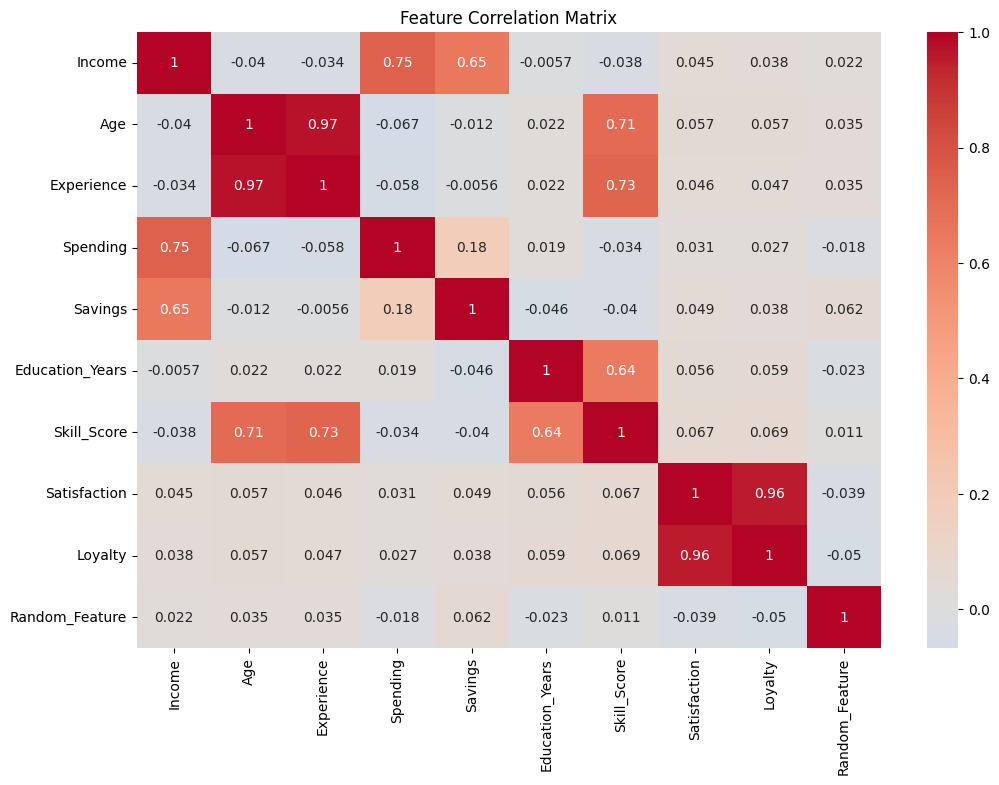

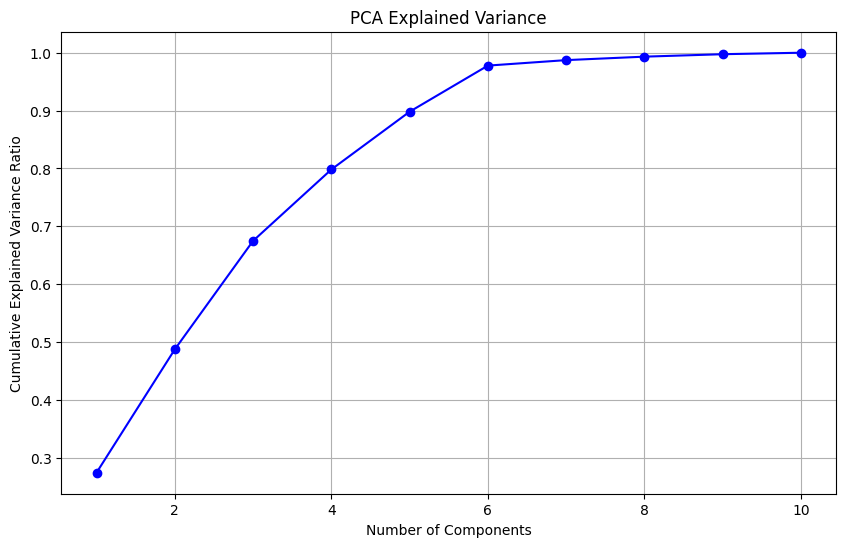

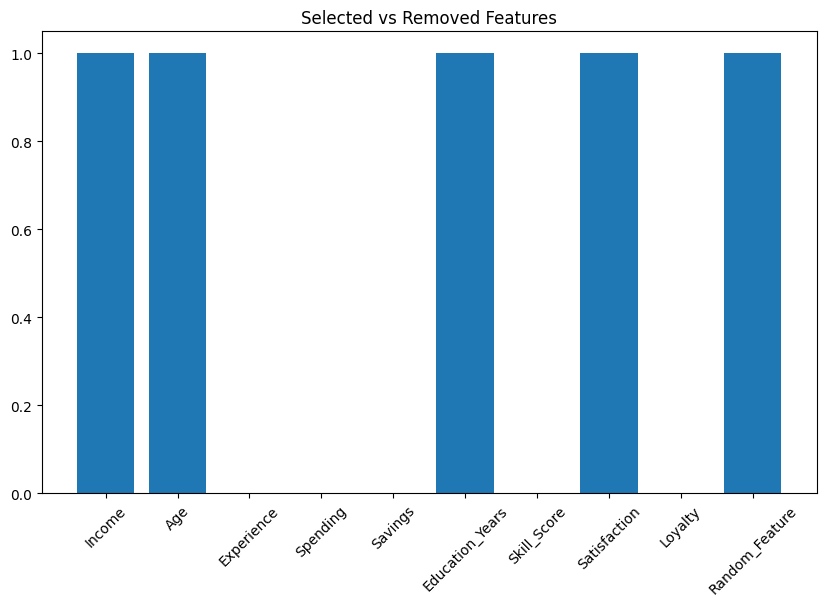

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

class FeatureSelector:
    def __init__(self, data, variance_threshold=0.8, correlation_threshold=0.7):
        self.data = data
        self.variance_threshold = variance_threshold
        self.correlation_threshold = correlation_threshold
        self.scaler = StandardScaler()
        self.removed_features = {}
        
    def select_features(self):
        """
        Comprehensive feature selection process
        """
        # Step 1: Initial analysis
        X_scaled = self.scaler.fit_transform(self.data)
        X_scaled = pd.DataFrame(X_scaled, columns=self.data.columns)
        
        # Step 2: Correlation analysis
        correlation_results = self._analyze_correlations()
        
        # Step 3: PCA analysis
        pca_results = self._perform_pca(X_scaled)
        
        # Step 4: Cluster analysis
        cluster_results = self._perform_clustering(X_scaled)
        
        # Step 5: Feature selection
        selected_features = self._select_final_features(
            correlation_results,
            pca_results,
            cluster_results
        )
        
        return selected_features
    
    def _analyze_correlations(self):
        """
        Analyze correlations between features
        """
        corr_matrix = self.data.corr()
        
        # Find highly correlated pairs
        high_corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i,j]) >= self.correlation_threshold:
                    high_corr_pairs.append({
                        'var1': corr_matrix.columns[i],
                        'var2': corr_matrix.columns[j],
                        'correlation': corr_matrix.iloc[i,j]
                    })
        
        return {
            'correlation_matrix': corr_matrix,
            'high_correlations': high_corr_pairs
        }
    
    def _perform_pca(self, X_scaled):
        """
        Perform PCA analysis
        """
        pca = PCA()
        components = pca.fit_transform(X_scaled)
        
        # Calculate loadings and explained variance
        loadings = pd.DataFrame(
            pca.components_.T,
            columns=[f'PC{i+1}' for i in range(len(self.data.columns))],
            index=self.data.columns
        )
        
        explained_variance = pd.DataFrame({
            'variance_ratio': pca.explained_variance_ratio_,
            'cumulative_variance': np.cumsum(pca.explained_variance_ratio_)
        })
        
        return {
            'loadings': loadings,
            'explained_variance': explained_variance,
            'pca_obj': pca
        }
    
    def _perform_clustering(self, X_scaled):
        """
        Perform clustering on features
        """
        # Transpose data to cluster features instead of samples
        X_features = X_scaled.T
        
        # Determine optimal number of clusters
        n_clusters = min(len(self.data.columns), 5)  # Maximum 5 clusters
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        feature_clusters = kmeans.fit_predict(X_features)
        
        return {
            'feature_clusters': feature_clusters,
            'cluster_centers': kmeans.cluster_centers_
        }
    
    def _select_final_features(self, correlation_results, pca_results, cluster_results):
        """
        Select final features based on all analyses
        """
        selected_features = set(self.data.columns)
        
        # 1. Remove highly correlated features
        for pair in correlation_results['high_correlations']:
            var1, var2 = pair['var1'], pair['var2']
            if var1 in selected_features and var2 in selected_features:
                # Remove feature with lower variance
                var1_variance = self.data[var1].var()
                var2_variance = self.data[var2].var()
                removed_var = var1 if var1_variance < var2_variance else var2
                selected_features.remove(removed_var)
                self.removed_features[removed_var] = f"High correlation with {var1 if removed_var == var2 else var2}"
        
        # 2. Use PCA loadings to identify important features
        loadings = pca_results['loadings']
        print(pca_results)
        cumulative_variance = pca_results['explained_variance']['cumulative_variance']
        n_components = np.argmax(cumulative_variance >= self.variance_threshold) + 1
        
        # Calculate feature importance scores based on loadings
        importance_scores = pd.Series(
            np.sqrt((loadings.iloc[:, :n_components] ** 2).sum(axis=1)),
            index=loadings.index
        )
        
        # Remove features with low importance
        low_importance_threshold = importance_scores.mean() - importance_scores.std()
        for feature in importance_scores[importance_scores < low_importance_threshold].index:
            if feature in selected_features:
                selected_features.remove(feature)
                self.removed_features[feature] = "Low importance in principal components"
        
        return list(selected_features)
    
    def explain_selection(self, selected_features):
        """
        Provide detailed explanation of feature selection
        """
        print("\nFeature Selection Analysis")
        print("========================")
        
        print("\n1. Selected Features:")
        for feature in selected_features:
            print(f"✓ {feature}")
            
        print("\n2. Removed Features and Reasons:")
        for feature, reason in self.removed_features.items():
            print(f"✗ {feature}: {reason}")
            
        # Additional statistics
        print("\n3. Selection Statistics:")
        print(f"Original features: {len(self.data.columns)}")
        print(f"Selected features: {len(selected_features)}")
        print(f"Reduction: {(1 - len(selected_features)/len(self.data.columns))*100:.1f}%")

# Generate example data with known relationships
def generate_example_data(n_samples=1000):
    np.random.seed(42)
    
    # Create base features
    income = np.random.normal(50000, 10000, n_samples)
    age = np.random.normal(40, 10, n_samples)
    experience = 0.8 * age + np.random.normal(0, 2, n_samples)  # Highly correlated with age
    
    spending = 0.6 * income + np.random.normal(0, 5000, n_samples)
    savings = 0.4 * income - 0.3 * spending + np.random.normal(0, 2000, n_samples)
    
    education_years = np.random.normal(16, 3, n_samples)
    skill_score = 0.7 * education_years + 0.3 * experience + np.random.normal(0, 1, n_samples)
    
    satisfaction = np.random.normal(7, 2, n_samples)
    loyalty = 0.8 * satisfaction + np.random.normal(0, 0.5, n_samples)
    
    random_feature = np.random.normal(0, 1, n_samples)  # Independent feature
    
    data = pd.DataFrame({
        'Income': income,
        'Age': age,
        'Experience': experience,
        'Spending': spending,
        'Savings': savings,
        'Education_Years': education_years,
        'Skill_Score': skill_score,
        'Satisfaction': satisfaction,
        'Loyalty': loyalty,
        'Random_Feature': random_feature
    })
    
    return data

# Run the analysis
data = generate_example_data()
selector = FeatureSelector(data, variance_threshold=0.8, correlation_threshold=0.7)
selected_features = selector.select_features()

# Explain results
selector.explain_selection(selected_features)

# Visualize the analysis
def visualize_analysis(data, selected_features):
    # 1. Correlation Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Matrix')
    plt.show()
    
    # 2. PCA Variance Explained
    pca = PCA()
    pca.fit(StandardScaler().fit_transform(data))
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
             np.cumsum(pca.explained_variance_ratio_), 'bo-')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance Ratio')
    plt.title('PCA Explained Variance')
    plt.grid(True)
    plt.show()
    
    # 3. Selected vs Removed Features
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(data.columns)), 
            [1 if col in selected_features else 0 for col in data.columns],
            tick_label=data.columns)
    plt.xticks(rotation=45)
    plt.title('Selected vs Removed Features')
    plt.show()

visualize_analysis(data, selected_features)